In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

%matplotlib inline

In [2]:
engine = create_engine('postgresql+psycopg2://localhost/creditsense')

df = pd.read_sql('SELECT * FROM credit_data', engine)

print("Shape:", df.shape)
print("\nFirst look:")
df.head()

Shape: (1000, 22)

First look:


,id,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,1,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,2,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,3,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,4,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,5,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id                        0
checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64


class
good    700
bad     300
Name: count, dtype: int64


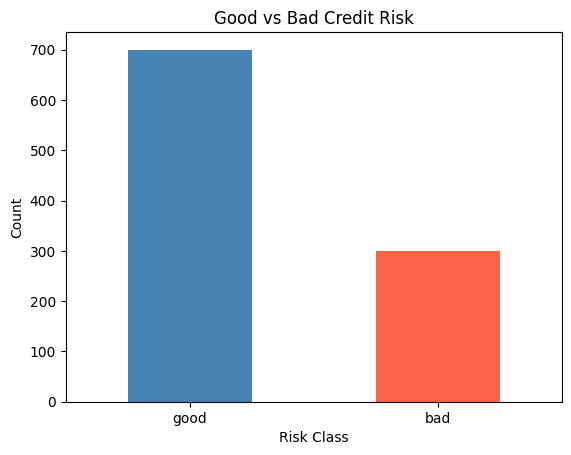

In [4]:
print(df['class'].value_counts())

df['class'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Good vs Bad Credit Risk')
plt.xlabel('Risk Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [6]:
import sys, os
project_root = os.path.dirname(os.getcwd())
sys.path.insert(0, project_root)

from src.pipeline import load_raw_data, build_features

raw = load_raw_data()
X, y = build_features(raw)

print(f"Features built: {X.shape[1]} columns, {X.shape[0]} rows")
print(f"Sample columns: {X.columns[:5].tolist()}")

Features built: 60 columns, 1000 rows
Sample columns: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age']


In [7]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 800 rows | Test: 200 rows


In [8]:
# Train XGBoost with tuned parameters
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

neg = sum(y_train == 0)
pos = sum(y_train == 1)
scale = neg / pos

param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale, random_state=42,
                  eval_metric='auc', verbosity=0),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best params:", grid.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}


In [9]:
# Evaluate
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)

print(f"ROC-AUC:  {auc:.3f}")
print(f"Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred, target_names=['good','bad']))

ROC-AUC:  0.802
Accuracy: 0.735
              precision    recall  f1-score   support

        good       0.85      0.75      0.80       140
         bad       0.55      0.70      0.61        60

    accuracy                           0.73       200
   macro avg       0.70      0.72      0.71       200
weighted avg       0.76      0.73      0.74       200



In [10]:
# Save model and feature list
import joblib

models_dir = os.path.join(project_root, 'src', 'models')
os.makedirs(models_dir, exist_ok=True)

joblib.dump(best_model,           os.path.join(models_dir, 'credit_risk_model.pkl'))
joblib.dump(X.columns.tolist(),   os.path.join(models_dir, 'feature_columns.pkl'))
X.assign(target=y).to_csv(os.path.join(project_root, 'data', 'processed_credit_data.csv'), index=False)

print("Model saved")
print("Feature columns saved")
print(f"Columns: {X.columns.tolist()[:5]} ...")

Model saved
Feature columns saved
Columns: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age'] ...
